All of the following is from [this guide](https://huggingface.co/learn/cookbook/semantic_segmentation_fine_tuning_inference).

In [1]:
from PIL import Image
import requests
import numpy as np
import os

from matplotlib import pyplot as plt
import matplotlib.patches as patches

In [2]:
%load_ext dotenv
%dotenv

In [3]:
from huggingface_hub import login
login(os.getenv('HUGGING_FACE_TOKEN'))

# 1. Preparing the Dataset

## 1.1 Loading the Dataset

In [4]:
from datasets import load_dataset
sidewalk_dataset_identifier = "segments/sidewalk-semantic"
dataset = load_dataset(sidewalk_dataset_identifier)
dataset

DatasetDict({
    train: Dataset({
        features: ['pixel_values', 'label'],
        num_rows: 1000
    })
})

In [5]:
dataset = dataset.shuffle(seed=42)['train']\
                 .train_test_split(test_size=0.2)

train_ds = dataset["train"]
test_ds  = dataset["test"]

In [6]:
import json
from huggingface_hub import hf_hub_download

id_to_label_tempfile_path = hf_hub_download(
    repo_id=sidewalk_dataset_identifier, 
    filename='id2label.json', 
    repo_type="dataset"
)

with open(id_to_label_tempfile_path, 'r') as file:
    data = json.load(file)
    
    # parse all values to integer and store a 
    # two-way association map
    id_to_label = { int(k): v for k, v in data.items() }
    label_to_id = { v: int(k) for k, v in data.items() }

In [7]:
# all colors are [R, G, B]
sidewalk_palette = [
  [0,   0,   0  ], # unlabeled
  [216, 82,  24 ], # flat-road
  [255, 255, 0  ], # flat-sidewalk
  [125, 46,  141], # flat-crosswalk
  [118, 171, 47 ], # flat-cyclinglane
  [161, 19,  46 ], # flat-parkingdriveway
  [255, 0,   0  ], # flat-railtrack
  [0,   128, 128], # flat-curb
  [190, 190, 0  ], # human-person
  [0,   255, 0  ], # human-rider
  [0,   0,   255], # vehicle-car
  [170, 0,   255], # vehicle-truck
  [84,  84,  0  ], # vehicle-bus
  [84,  170, 0  ], # vehicle-tramtrain
  [84,  255, 0  ], # vehicle-motorcycle
  [170, 84,  0  ], # vehicle-bicycle
  [170, 170, 0  ], # vehicle-caravan
  [170, 255, 0  ], # vehicle-cartrailer
  [255, 84,  0  ], # construction-building
  [255, 170, 0  ], # construction-door
  [255, 255, 0  ], # construction-wall
  [33,  138, 200], # construction-fenceguardrail
  [0,   170, 127], # construction-bridge
  [0,   255, 127], # construction-tunnel
  [84,  0,   127], # construction-stairs
  [84,  84,  127], # object-pole
  [84,  170, 127], # object-trafficsign
  [84,  255, 127], # object-trafficlight
  [170, 0,   127], # nature-vegetation
  [170, 84,  127], # nature-terrain
  [170, 170, 127], # sky
  [170, 255, 127], # void-ground
  [255, 0,   127], # void-dynamic
  [255, 84,  127], # void-static
  [255, 170, 127], # void-unclear
]

## 1.2 Visualizing the Dataset

Display the legend separately:

In [14]:
legend_patches = [
    patches.Patch(color=np.array(color)/255, label=label) \
    for label, color \
    in zip(id_to_label.values(), sidewalk_palette)
]

def show_legend():
    fig, ax = plt.subplots(figsize=(18, 2))

    ax.legend(
        handles=legend_patches, 
        loc='center', 
        bbox_to_anchor=(0.5, 0.5), 
        ncol=5, 
        fontsize=20
    )

    ax.axis('off')
    plt.show()

Displaying 5  examples:

In [15]:
def show_examples():
    for i in range(5):
        image = train_ds[i]

        fig, ax = plt.subplots(1, 3, figsize=(18, 6))

        # Show the original image
        ax[0].imshow(image['pixel_values'])
        ax[0].set_title('Original Image')
        ax[0].axis('off')

        mask_np = np.array(image['label'])

        # Create a new empty RGB image
        colored_mask = np.zeros(
            (mask_np.shape[0], mask_np.shape[1], 3), 
            dtype=np.uint8
        )

        # Assign colors to each value in the mask
        for label_id, color in enumerate(sidewalk_palette):
            colored_mask[mask_np == label_id] = color

        colored_mask_img = Image.fromarray(colored_mask)

        # Show the segmentation mask
        ax[1].imshow(colored_mask_img)
        ax[1].set_title('Segmentation Mask')
        ax[1].axis('off')

        # convert to RGBA to support transparency
        image_rgba = image['pixel_values'].convert("RGBA")
        colored_mask_rgba = colored_mask_img.convert("RGBA")
        
        alpha = 128
        image_2_with_alpha = Image.new(
            "RGBA", 
            colored_mask_rgba.size
        )
        
        # overlap
        
        for x in range(colored_mask_rgba.width):
            for y in range(colored_mask_rgba.height):
                r, g, b, a = colored_mask_rgba.getpixel((x, y))
                image_2_with_alpha.putpixel((x, y), (r, g, b, alpha))

        superposed = Image.alpha_composite(image_rgba, image_2_with_alpha)

        # Show the mask overlay
        ax[2].imshow(superposed)
        ax[2].set_title('Mask Overlay')
        ax[2].axis('off')

        plt.show()

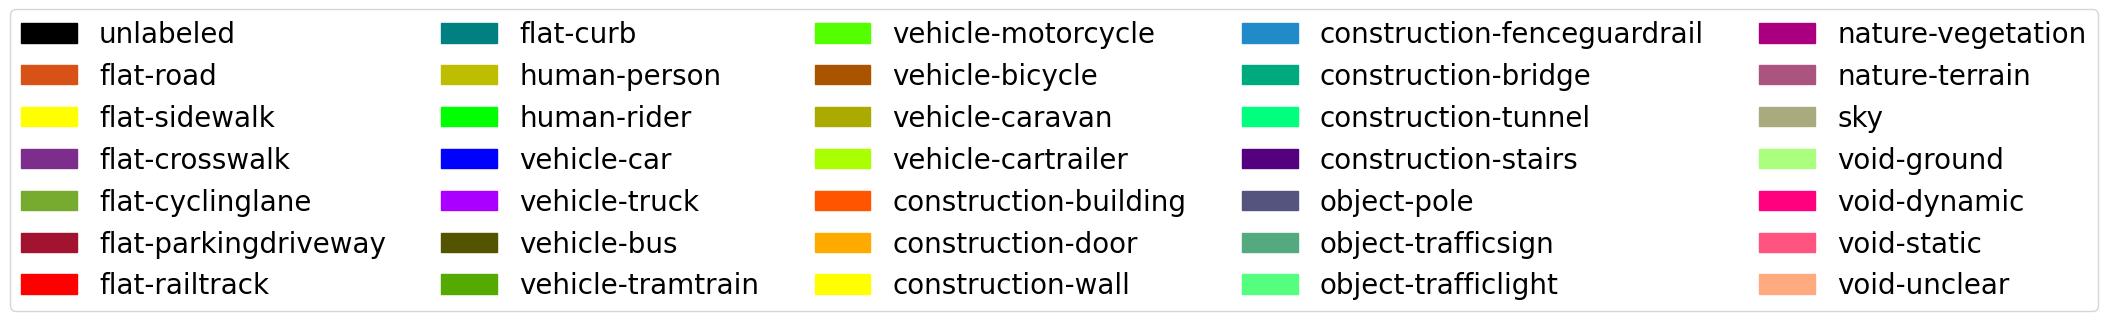

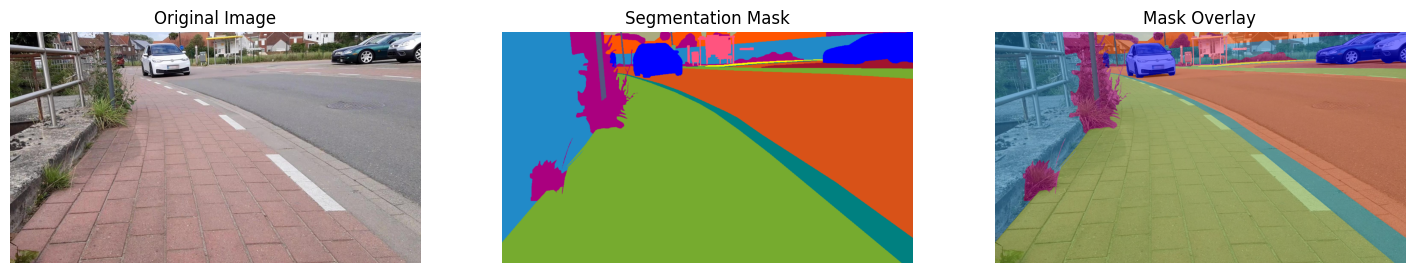

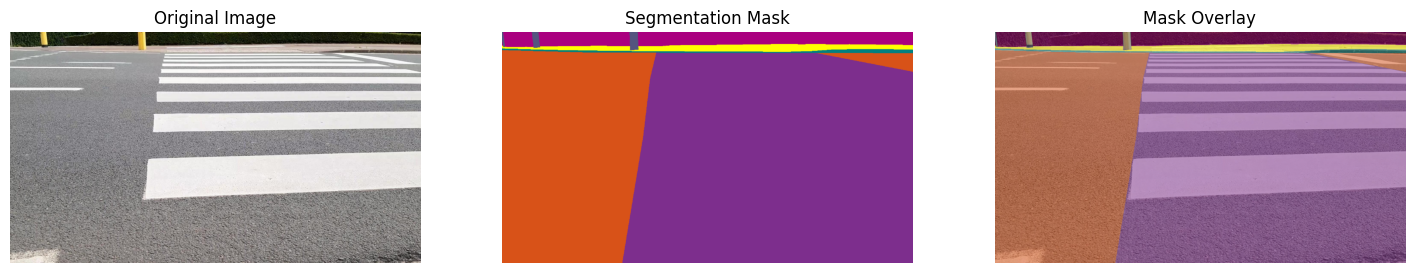

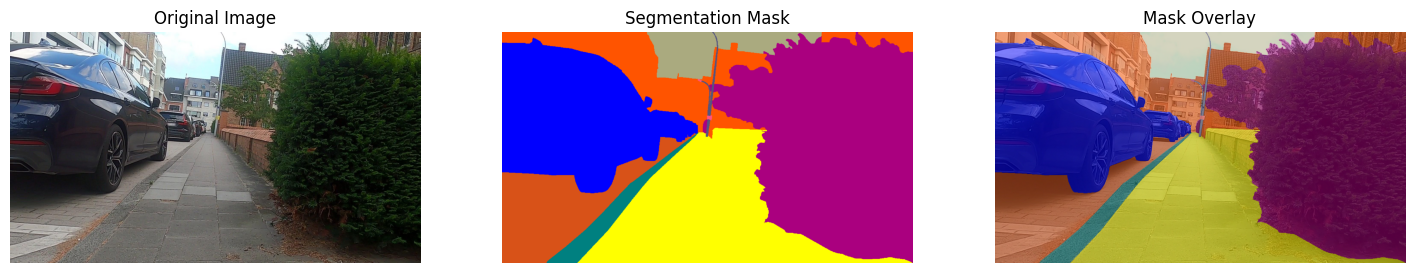

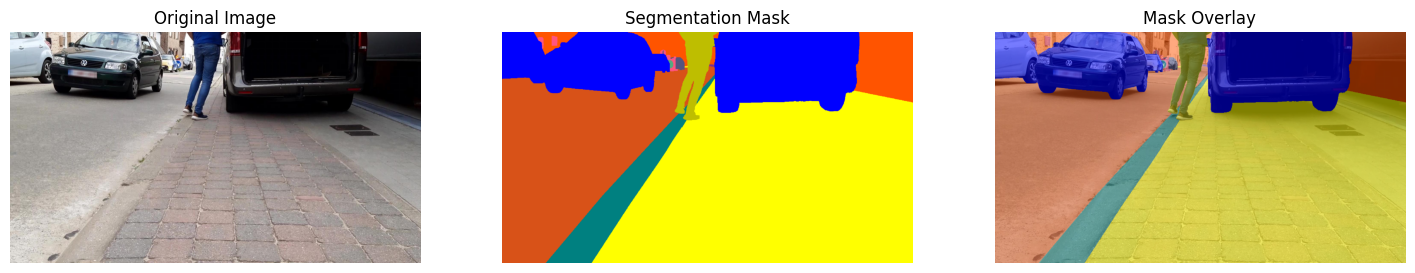

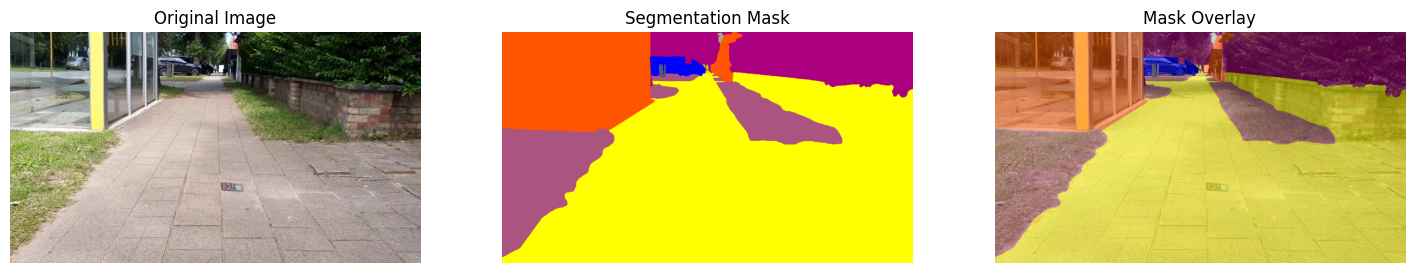

In [10]:
show_legend()
show_examples()

## 1.3 Checking the Distribution of Class Occurences

In [12]:
class_counts = np.zeros(len(id_to_label))

for example in train_ds:
    mask_np = np.array(example['label'])
    unique, counts = np.unique(mask_np, return_counts=True)
    for u, c in zip(unique, counts):
        class_counts[u] += c

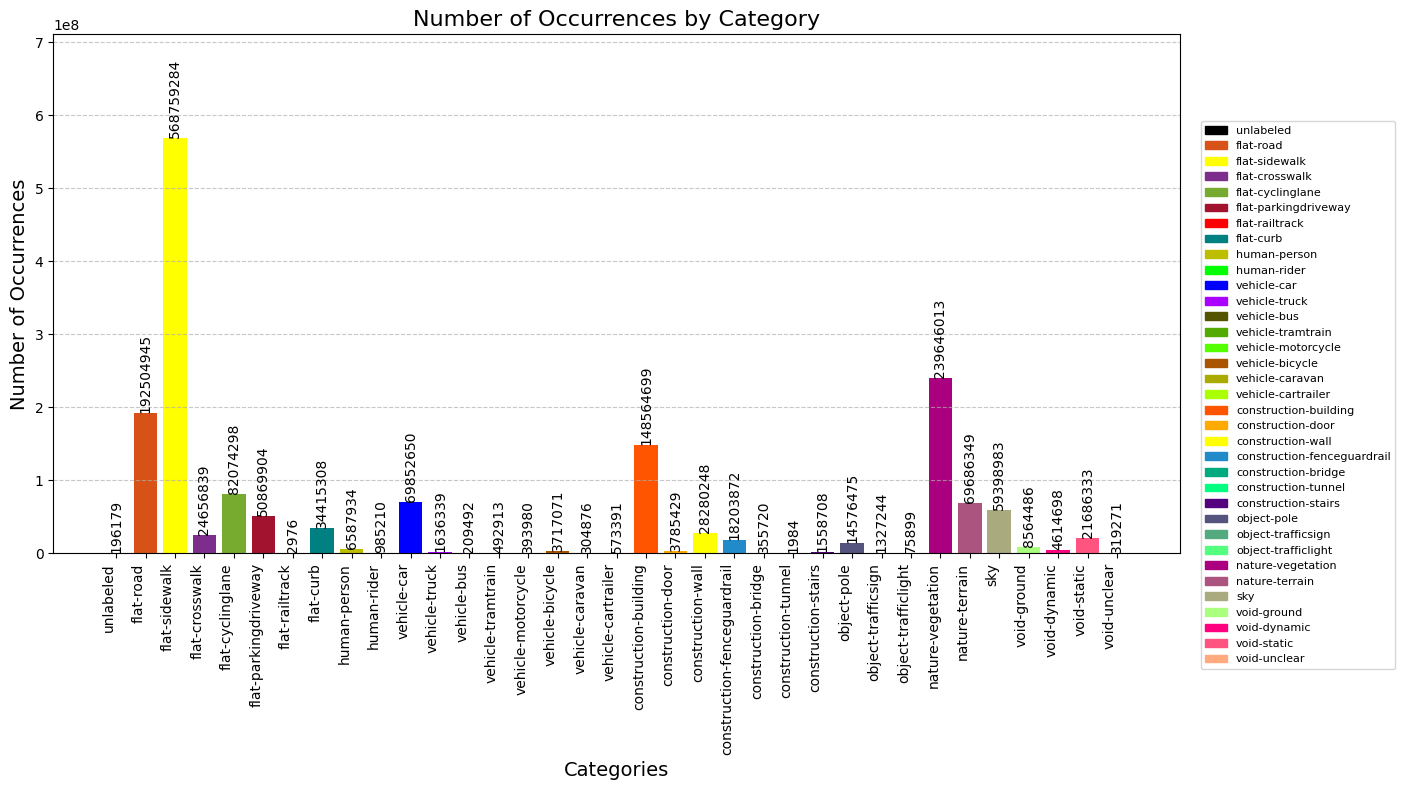

In [16]:
labels = list(id_to_label.values())

# Normalize colors to be in the range [0, 1]
normalized_palette = [
    tuple(c / 255 for c in color)\
    for color in sidewalk_palette
]

# Visualization
fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.bar(
    range(len(labels)), 
    class_counts, 
    color=[normalized_palette[i] for i in range(len(labels))]
)

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=90, ha="right")

ax.set_xlabel("Categories", fontsize=14)
ax.set_ylabel("Number of Occurrences", fontsize=14)
ax.set_title("Number of Occurrences by Category", fontsize=16)

ax.grid(axis="y", linestyle="--", alpha=0.7)

# Adjust the y-axis limit
y_max = max(class_counts)
ax.set_ylim(0, y_max * 1.25)

for bar in bars:
    height = int(bar.get_height())
    # Adjust the text location
    offset = 10
    
    ax.text(
        bar.get_x() + bar.get_width() / 2.0, 
        height + offset, 
        f"{height}",
        ha="center", 
        va="bottom", 
        rotation=90, 
        fontsize=10, 
        color='black'
    )

fig.legend(
    handles=legend_patches, 
    loc='center left', 
    bbox_to_anchor=(1, 0.5), 
    ncol=1, 
    fontsize=8
)

plt.tight_layout()
plt.show()

## 1.4 Additional Data Augmentation

This is a simple way to perform data augmentations to our images to boost the performance, via [albumentations](https://albumentations.ai/).

In [21]:
import albumentations as A
from transformers import SegformerImageProcessor

image_processor = SegformerImageProcessor()

albumentations_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=30, p=0.7),
    A.RandomResizedCrop(size=(512, 512), scale=(0.8, 1.0), ratio=(0.75, 1.33), p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=0.5),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=25, val_shift_limit=20, p=0.5),
    A.GaussianBlur(blur_limit=(3, 5), p=0.3),
    A.GaussNoise(p=0.4),
])

def train_transforms(example_batch):
    augmented = [
        albumentations_transform(image=np.array(image), mask=np.array(label))
        for image, label in zip(example_batch['pixel_values'], example_batch['label'])
    ]
    augmented_images = [item['image'] for item in augmented]
    augmented_labels = [item['mask'] for item in augmented]
    inputs = image_processor(augmented_images, augmented_labels)
    return inputs

def val_transforms(example_batch):
    images = [x for x in example_batch['pixel_values']]
    labels = [x for x in example_batch['label']]
    inputs = image_processor(images, labels)
    return inputs


# Set transforms
train_ds.set_transform(train_transforms)
test_ds.set_transform(val_transforms)

# 2. Training the Model

## 2.1 Loading and Configuring the Model

The model is loading the Segformer model [nvidia/mit-b0](https://huggingface.co/nvidia/mit-b0). We'll probably just want to swap this out for SAM2 (or even keep it as-is, if we can, as HuggingFace makes all of this code analogous for SAM2).

In [22]:
from transformers import SegformerForSemanticSegmentation

pretrained_model_name = "nvidia/mit-b0"
model = SegformerForSemanticSegmentation.from_pretrained(
    pretrained_model_name,
    id2label=id_to_label,
    label2id=label_to_id
)

Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b0 and are newly initialized: ['decode_head.batch_norm.bias', 'decode_head.batch_norm.num_batches_tracked', 'decode_head.batch_norm.running_mean', 'decode_head.batch_norm.running_var', 'decode_head.batch_norm.weight', 'decode_head.classifier.bias', 'decode_head.classifier.weight', 'decode_head.linear_c.0.proj.bias', 'decode_head.linear_c.0.proj.weight', 'decode_head.linear_c.1.proj.bias', 'decode_head.linear_c.1.proj.weight', 'decode_head.linear_c.2.proj.bias', 'decode_head.linear_c.2.proj.weight', 'decode_head.linear_c.3.proj.bias', 'decode_head.linear_c.3.proj.weight', 'decode_head.linear_fuse.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [31]:
from transformers import TrainingArguments

output_dir = "test-segformer-b0-segments-sidewalk-finetuned"

training_args = TrainingArguments(
    output_dir=output_dir,
    learning_rate=6e-5,
    num_train_epochs=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    save_total_limit=2,
    eval_strategy="steps",
    save_strategy="steps",
    save_steps=20,
    eval_steps=20,
    logging_steps=1,
    eval_accumulation_steps=5,
    load_best_model_at_end=True,
    report_to='wandb'
)

In [32]:
import evaluate
evaluate.logging.set_verbosity_error()

In [36]:
import torch
from torch import nn
import multiprocessing
import warnings

metric = evaluate.load("mean_iou")

def compute_metrics(eval_pred):
    with torch.no_grad():
        logits, labels = eval_pred
        logits_tensor = torch.from_numpy(logits)
        
        # scale the logits to the size of the label
        logits_tensor = nn.functional.interpolate(
            logits_tensor,
            size=labels.shape[-2:],
            mode="bilinear",
            align_corners=False,
        ).argmax(dim=1)

        # currently using _compute instead of compute: 
        # https://github.com/huggingface/evaluate/pull/328#issuecomment-1286866576
        pred_labels = logits_tensor.detach().cpu().numpy()
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)
            metrics = metric._compute(
                predictions=pred_labels,
                references=labels,
                num_labels=len(id_to_label),
                ignore_index=0,
                reduce_labels=image_processor.do_reduce_labels,
            )

        # add per category metrics as individual key-value pairs
        per_category_accuracy = metrics.pop("per_category_accuracy").tolist()
        per_category_iou = metrics.pop("per_category_iou").tolist()

        metrics.update({f"accuracy_{id_to_label[i]}": v for i, v in enumerate(per_category_accuracy)})
        metrics.update({f"iou_{id_to_label[i]}": v for i, v in enumerate(per_category_iou)})

        return metrics

## 2.2 Train the Model

In [37]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    processing_class=image_processor,
    compute_metrics=compute_metrics,
)

In [38]:
trainer.train()

/home/mufaro/Programming/parklet-vision/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss,Validation Loss,Mean Iou,Mean Accuracy,Overall Accuracy,Accuracy Unlabeled,Accuracy Flat-road,Accuracy Flat-sidewalk,Accuracy Flat-crosswalk,Accuracy Flat-cyclinglane,Accuracy Flat-parkingdriveway,Accuracy Flat-railtrack,Accuracy Flat-curb,Accuracy Human-person,Accuracy Human-rider,Accuracy Vehicle-car,Accuracy Vehicle-truck,Accuracy Vehicle-bus,Accuracy Vehicle-tramtrain,Accuracy Vehicle-motorcycle,Accuracy Vehicle-bicycle,Accuracy Vehicle-caravan,Accuracy Vehicle-cartrailer,Accuracy Construction-building,Accuracy Construction-door,Accuracy Construction-wall,Accuracy Construction-fenceguardrail,Accuracy Construction-bridge,Accuracy Construction-tunnel,Accuracy Construction-stairs,Accuracy Object-pole,Accuracy Object-trafficsign,Accuracy Object-trafficlight,Accuracy Nature-vegetation,Accuracy Nature-terrain,Accuracy Sky,Accuracy Void-ground,Accuracy Void-dynamic,Accuracy Void-static,Accuracy Void-unclear,Iou Unlabeled,Iou Flat-road,Iou Flat-sidewalk,Iou Flat-crosswalk,Iou Flat-cyclinglane,Iou Flat-parkingdriveway,Iou Flat-railtrack,Iou Flat-curb,Iou Human-person,Iou Human-rider,Iou Vehicle-car,Iou Vehicle-truck,Iou Vehicle-bus,Iou Vehicle-tramtrain,Iou Vehicle-motorcycle,Iou Vehicle-bicycle,Iou Vehicle-caravan,Iou Vehicle-cartrailer,Iou Construction-building,Iou Construction-door,Iou Construction-wall,Iou Construction-fenceguardrail,Iou Construction-bridge,Iou Construction-tunnel,Iou Construction-stairs,Iou Object-pole,Iou Object-trafficsign,Iou Object-trafficlight,Iou Nature-vegetation,Iou Nature-terrain,Iou Sky,Iou Void-ground,Iou Void-dynamic,Iou Void-static,Iou Void-unclear
20,2.289400,1.994725,0.114089,0.161340,0.647788,nan,0.584510,0.919236,0.000000,0.419531,0.000160,nan,0.000387,0.000000,0.000000,0.194587,0.000000,0.000000,nan,0.000000,0.000000,nan,0.000000,0.800898,0.000000,0.000000,0.000000,0.000000,nan,0.000000,0.000000,0.000000,0.000000,0.939776,0.191208,0.789919,0.000000,0.000000,0.000000,0.000000,0.000000,0.431862,0.680330,0.000000,0.327719,0.000160,nan,0.000385,0.000000,0.000000,0.179396,0.000000,0.000000,nan,0.000000,0.000000,nan,0.000000,0.381414,0.000000,0.000000,0.000000,0.000000,nan,0.000000,0.000000,0.000000,0.000000,0.639016,0.181292,0.715185,0.000000,0.000000,0.000000,0.000000
40,1.887100,1.836406,0.121296,0.172695,0.668998,nan,0.620836,0.922258,0.000000,0.433459,0.000104,nan,0.000307,0.000000,0.000000,0.410232,0.000000,0.000000,nan,0.000000,0.000000,nan,0.000000,0.797970,0.000000,0.000000,0.000000,0.000000,nan,0.000000,0.000000,0.000000,0.000000,0.956326,0.237988,0.801381,0.000000,0.000000,0.000000,0.000000,0.000000,0.447170,0.696287,0.000000,0.362632,0.000104,nan,0.000306,0.000000,0.000000,0.358571,0.000000,0.000000,nan,0.000000,0.000000,nan,0.000000,0.420440,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.628084,0.220899,0.746978,0.000000,0.000000,0.000000,0.000000
60,2.115200,1.797162,0.135996,0.184363,0.686310,nan,0.647226,0.919104,0.000000,0.431935,0.000077,nan,0.000317,0.000000,0.000000,0.529737,0.000000,0.000000,nan,0.000000,0.000000,nan,0.000000,0.835853,0.000000,0.000000,0.000000,0.000000,nan,0.000000,0.000000,0.000000,0.000000,0.948782,0.399999,0.817863,0.000000,0.000000,0.000000,0.000000,0.000000,0.455697,0.705188,0.000000,0.383615,0.000077,nan,0.000316,0.000000,0.000000,0.441034,0.000000,0.000000,nan,0.000000,0.000000,nan,0.000000,0.441971,0.000000,0.000000,0.000000,0.000000,nan,0.000000,0.000000,0.000000,0.000000,0.660171,0.358131,0.769677,0.000000,0.000000,0.000000,0.000000
80,1.710900,1.725653,0.143470,0.193073,0.698479,nan,0.682333,0.915102,0.000000,0.457815,0.000036,nan,0.000032,0.000000,0.000000,0.617448,0.000000,0.000000,nan,0.000000,0.000000,nan,0.000000,0.833221,0.000000,0.000000,0.000000,0.000000,nan,0.000000,0.000000,0.000000,0.000000,0.935471,0.492284,0.858449,0.000000,0.000000,0.000000,0.000000,0.000000,0.453885,0.714508,0.000000,0.392683,0.000036,nan,0.000032,0.000000,0.000000,0.504422,0.000000,0.000000,nan,0.000000,0.000000,

/home/mufaro/Programming/parklet-vision/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/home/mufaro/Programming/parklet-vision/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/home/mufaro/Programming/parklet-vision/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/home/mufaro/Programming/parklet-vision/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  

TrainOutput(global_step=100, training_loss=2.003353799581528, metrics={'train_runtime': 1141.8922, 'train_samples_per_second': 0.701, 'train_steps_per_second': 0.088, 'total_flos': 1.40543791202304e+16, 'train_loss': 2.003353799581528, 'epoch': 1.0})

# 3. Evaluate Model Performance

## 3.1 Evaluate Model on a New Image

In [39]:
import requests
from transformers import pipeline
import numpy as np
from PIL import Image, ImageDraw

NEW_IMAGE_URL = "https://images.unsplash.com/photo-1594098742644-314fedf61fb6?q=80&w=2672&auto=format&fit=crop&ixlib=rb-4.0.3&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D"

image = Image.open(requests.get(NEW_IMAGE_URL, stream=True).raw)

image_segmentator = pipeline(
    "image-segmentation", 
    model="sergiopaniego/test-segformer-b0-segments-sidewalk-finetuned"
)

results = image_segmentator(image)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/14.9M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/372 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cpu


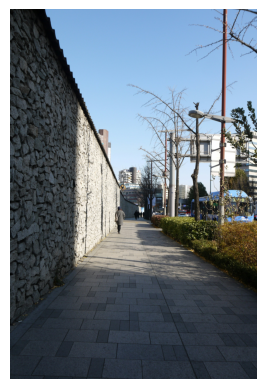

In [40]:
plt.imshow(image)
plt.axis('off')
plt.show()

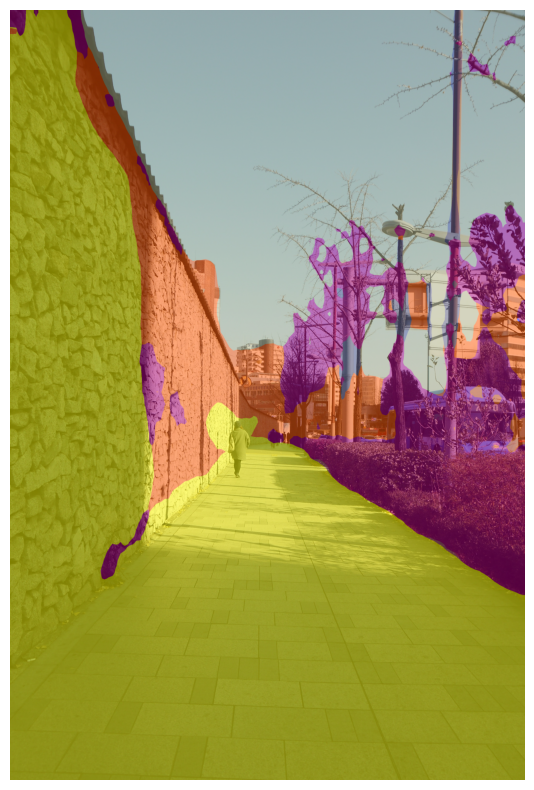

In [41]:
image_array = np.array(image)

segmentation_map = np.zeros_like(image_array)

for result in results:
    mask = np.array(result['mask'])
    label = result['label']

    label_index = list(id_to_label.values()).index(label)

    color = sidewalk_palette[label_index]

    for c in range(3):
        segmentation_map[:, :, c] = np.where(mask, color[c], segmentation_map[:, :, c])

plt.figure(figsize=(10, 10))
plt.imshow(image_array)
plt.imshow(segmentation_map, alpha=0.5)
plt.axis('off')
plt.show()

## 3.2 Evaluate on the Test Set

In [42]:
metrics = trainer.evaluate(test_ds)
metrics

/home/mufaro/Programming/parklet-vision/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 1.706722378730774, 'eval_mean_iou': 0.1434204779197481, 'eval_mean_accuracy': 0.1939812463320379, 'eval_overall_accuracy': 0.6999826850045654, 'eval_accuracy_unlabeled': nan, 'eval_accuracy_flat-road': 0.6823892200133785, 'eval_accuracy_flat-sidewalk': 0.9130500478131404, 'eval_accuracy_flat-crosswalk': 0.0, 'eval_accuracy_flat-cyclinglane': 0.465049118199498, 'eval_accuracy_flat-parkingdriveway': 0.0002711798099963102, 'eval_accuracy_flat-railtrack': nan, 'eval_accuracy_flat-curb': 0.00010654018636640749, 'eval_accuracy_human-person': 0.0, 'eval_accuracy_human-rider': 0.0, 'eval_accuracy_vehicle-car': 0.6661360627897227, 'eval_accuracy_vehicle-truck': 0.0, 'eval_accuracy_vehicle-bus': 0.0, 'eval_accuracy_vehicle-tramtrain': nan, 'eval_accuracy_vehicle-motorcycle': 0.0, 'eval_accuracy_vehicle-bicycle': 0.0, 'eval_accuracy_vehicle-caravan': nan, 'eval_accuracy_vehicle-cartrailer': 0.0, 'eval_accuracy_construction-building': 0.817713361644721, 'eval_accuracy_construction-do

In [43]:
metrics

{'eval_loss': 1.706722378730774,
 'eval_mean_iou': 0.1434204779197481,
 'eval_mean_accuracy': 0.1939812463320379,
 'eval_overall_accuracy': 0.6999826850045654,
 'eval_accuracy_unlabeled': nan,
 'eval_accuracy_flat-road': 0.6823892200133785,
 'eval_accuracy_flat-sidewalk': 0.9130500478131404,
 'eval_accuracy_flat-crosswalk': 0.0,
 'eval_accuracy_flat-cyclinglane': 0.465049118199498,
 'eval_accuracy_flat-parkingdriveway': 0.0002711798099963102,
 'eval_accuracy_flat-railtrack': nan,
 'eval_accuracy_flat-curb': 0.00010654018636640749,
 'eval_accuracy_human-person': 0.0,
 'eval_accuracy_human-rider': 0.0,
 'eval_accuracy_vehicle-car': 0.6661360627897227,
 'eval_accuracy_vehicle-truck': 0.0,
 'eval_accuracy_vehicle-bus': 0.0,
 'eval_accuracy_vehicle-tramtrain': nan,
 'eval_accuracy_vehicle-motorcycle': 0.0,
 'eval_accuracy_vehicle-bicycle': 0.0,
 'eval_accuracy_vehicle-caravan': nan,
 'eval_accuracy_vehicle-cartrailer': 0.0,
 'eval_accuracy_construction-building': 0.817713361644721,
 'eval_a